## CME FEB 2025

In [ ]:
import pandas as pd
import numpy as np

cme_feb_2025 = pd.read_csv("../../data/raw/CME/CME_FEB_2025.csv")
cme_feb_2025 = cme_feb_2025.reset_index(drop = True)
cme_feb_2025["time"] = pd.to_datetime(cme_feb_2025["time"],unit="s") 

In [ ]:
cme_feb_2025

,time,open,high,low,close,Volume
0,2024-08-01 05:25:00,95.5800,95.5800,95.5800,95.5800,5
1,2024-08-01 05:26:00,95.5800,95.5800,95.5800,95.5800,2
2,2024-08-01 05:41:00,95.5850,95.5850,95.5850,95.5850,6
3,2024-08-01 06:12:00,95.5800,95.5800,95.5800,95.5800,2
4,2024-08-01 06:19:00,95.5800,95.5800,95.5800,95.5800,8
...,...,...,...,...,...,...
36813,2025-02-28 16:16:00,95.6675,95.6675,95.6675,95.6675,1
36814,2025-02-28 16:37:00,95.6700,95.6700,95.6700,95.6700,4285
36815,2025-02-28 16:43:00,95.6700,95.6700,95.6700,95.6700,2
36816,2025-02-28 17:21:00,95.6700,95.6700,95.6700,95.6700,1


## CME MAR 2025

In [7]:
cme_mar_2025 = pd.read_csv("../../data/raw/CME/CME_MAR_2025.csv")
cme_mar_2025 = cme_mar_2025.reset_index(drop = True)
cme_mar_2025["time"] = pd.to_datetime(cme_mar_2025["time"],unit="s") 

In [8]:
cme_mar_2025

,time,open,high,low,close,Volume
0,2024-12-01 23:05:00,95.700,95.700,95.700,95.700,3
1,2024-12-01 23:36:00,95.700,95.700,95.700,95.700,3
2,2024-12-02 00:13:00,95.695,95.695,95.695,95.695,2
3,2024-12-02 01:10:00,95.695,95.695,95.695,95.695,117
4,2024-12-02 02:27:00,95.690,95.690,95.690,95.690,19
...,...,...,...,...,...,...
9251,2025-03-31 19:54:00,95.670,95.670,95.670,95.670,4
9252,2025-03-31 19:56:00,95.670,95.670,95.670,95.670,12
9253,2025-03-31 20:17:00,95.670,95.670,95.670,95.670,74
9254,2025-03-31 20:50:00,95.670,95.670,95.670,95.670,5


## Merge and then calculate probabilities

In [9]:
feb = cme_feb_2025.copy()
feb["time"] = pd.to_datetime(feb["time"], unit="s")
feb = feb.sort_values("time").set_index("time")

feb = feb.add_suffix("_feb_2025")

mar = cme_mar_2025.copy()
mar["time"] = pd.to_datetime(mar["time"], unit="s")
mar = mar.sort_values("time").set_index("time")

mar = mar.add_suffix("_mar_2025")

feb_aligned = feb.reindex(mar.index, method="ffill")


final_df = pd.concat([mar, feb_aligned], axis=1)
final_df = final_df.reset_index()

In [10]:
final_df

,time,open_mar_2025,high_mar_2025,low_mar_2025,close_mar_2025,Volume_mar_2025,open_feb_2025,high_feb_2025,low_feb_2025,close_feb_2025,Volume_feb_2025
0,2024-12-01 23:05:00,95.700,95.700,95.700,95.700,3,95.645,95.645,95.645,95.645,26
1,2024-12-01 23:36:00,95.700,95.700,95.700,95.700,3,95.645,95.645,95.645,95.645,26
2,2024-12-02 00:13:00,95.695,95.695,95.695,95.695,2,95.645,95.645,95.645,95.645,28
3,2024-12-02 01:10:00,95.695,95.695,95.695,95.695,117,95.645,95.645,95.645,95.645,217
4,2024-12-02 02:27:00,95.690,95.690,95.690,95.690,19,95.645,95.645,95.645,95.645,395
...,...,...,...,...,...,...,...,...,...,...,...
9251,2025-03-31 19:54:00,95.670,95.670,95.670,95.670,4,95.670,95.670,95.670,95.670,2
9252,2025-03-31 19:56:00,95.670,95.670,95.670,95.670,12,95.670,95.670,95.670,95.670,2
9253,2025-03-31 20:17:00,95.670,95.670,95.670,95.670,74,95.670,95.670,95.670,95.670,2
9254,2025-03-31 20:50:00,95.670,95.670,95.670,95.670,5,95.670,95.670,95.670,95.670,2


## Calculating Implied Probabilities

In [ ]:
meeting_day = 19
days_in_march = 31

N = meeting_day           
M = days_in_march - N        

imp_df = pd.DataFrame()
imp_df["time"] = final_df["time"].copy()

imp_df["effr_avg_feb"] = 100 - final_df["close_feb_2025"]
imp_df["effr_avg_mar"] = 100 - final_df["close_mar_2025"]

imp_df["effr_end_feb"] = imp_df["effr_avg_feb"]
imp_df["effr_start_mar"] = imp_df["effr_end_feb"]
imp_df["volume"] = final_df["Volume_mar_2025"]


In [12]:
imp_df

,time,effr_avg_feb,effr_avg_mar,effr_end_feb,effr_start_mar
0,2024-12-01 23:05:00,4.355,4.300,4.355,4.355
1,2024-12-01 23:36:00,4.355,4.300,4.355,4.355
2,2024-12-02 00:13:00,4.355,4.305,4.355,4.355
3,2024-12-02 01:10:00,4.355,4.305,4.355,4.355
4,2024-12-02 02:27:00,4.355,4.310,4.355,4.355
...,...,...,...,...,...
9251,2025-03-31 19:54:00,4.330,4.330,4.330,4.330
9252,2025-03-31 19:56:00,4.330,4.330,4.330,4.330
9253,2025-03-31 20:17:00,4.330,4.330,4.330,4.330
9254,2025-03-31 20:50:00,4.330,4.330,4.330,4.330


In [13]:
imp_df["effr_end_mar"] = (
    imp_df["effr_avg_mar"] - (N / (N + M)) * imp_df["effr_start_mar"]
) / (M / (N + M))

In [ ]:
imp_df["delta_effr"] = imp_df["effr_end_mar"] - imp_df["effr_start_mar"]
imp_df["num_hikes"] = imp_df["delta_effr"] / 0.25

imp_df["hikes_floor"] = np.floor(imp_df["num_hikes"])
imp_df["hikes_decimal"] = imp_df["num_hikes"] - imp_df["hikes_floor"]


states = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

state_to_col = {
    -4: "prob_cut_100",
    -3: "prob_cut_75",
    -2: "prob_cut_50",
    -1: "prob_cut_25",
     0: "prob_no_change",
     1: "prob_hike_25",
     2: "prob_hike_50",
     3: "prob_hike_75",
     4: "prob_hike_100"
}

for col in state_to_col.values():
    imp_df[col] = 0.0

for i, row in imp_df.iterrows():
    floor = int(row["hikes_floor"])
    decimal = row["hikes_decimal"]
    
    p_low = 1 - decimal
    p_high = decimal
    
    if floor in state_to_col:
        imp_df.at[i, state_to_col[floor]] += p_low

    if (floor + 1) in state_to_col:
        imp_df.at[i, state_to_col[floor + 1]] += p_high

In [15]:
imp_df

,time,effr_avg_feb,effr_avg_mar,effr_end_feb,effr_start_mar,effr_end_mar,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50
0,2024-12-01 23:05:00,4.355,4.300,4.355,4.355,4.212917,-0.142083,-0.568333,-1.0,0.431667,0.0,0.568333,0.431667,0.0,0.0
1,2024-12-01 23:36:00,4.355,4.300,4.355,4.355,4.212917,-0.142083,-0.568333,-1.0,0.431667,0.0,0.568333,0.431667,0.0,0.0
2,2024-12-02 00:13:00,4.355,4.305,4.355,4.355,4.225833,-0.129167,-0.516667,-1.0,0.483333,0.0,0.516667,0.483333,0.0,0.0
3,2024-12-02 01:10:00,4.355,4.305,4.355,4.355,4.225833,-0.129167,-0.516667,-1.0,0.483333,0.0,0.516667,0.483333,0.0,0.0
4,2024-12-02 02:27:00,4.355,4.310,4.355,4.355,4.238750,-0.116250,-0.465000,-1.0,0.535000,0.0,0.465000,0.535000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9251,2025-03-31 19:54:00,4.330,4.330,4.330,4.330,4.330000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,1.000000,0.0,0.0
9252,2025-03-31 19:56:00,4.330,4.330,4.330,4.330,4.330000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,1.000000,0.0,0.0
9253,2025-03-31 20:17:00,4.330,4.330,4.330,4.330,4.330000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,1.000000,0.0,0.0
9254,2025-03-31 20:50:00,4.330,4.330,4.330,4.330,4.330000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,1.000000,0.0,0.0


In [16]:
imp_df["time"] = pd.to_datetime(imp_df["time"], utc=True)

## Filtering Based on Announcement Time

In [18]:
fomc_2025_utc = {
    "January 2025": pd.Timestamp("2025-01-29 19:00:00", tz="UTC"),
    "March 2025": pd.Timestamp("2025-03-19 18:00:00", tz="UTC"),
    "May 2025": pd.Timestamp("2025-05-07 18:00:00", tz="UTC"),
    "June 2025": pd.Timestamp("2025-06-18 18:00:00", tz="UTC"),
    "July 2025": pd.Timestamp("2025-07-30 18:00:00", tz="UTC"),
    "September 2025": pd.Timestamp("2025-09-17 18:00:00", tz="UTC"),
    "October 2025": pd.Timestamp("2025-10-29 19:00:00", tz="UTC"),
    "December 2025": pd.Timestamp("2025-12-10 19:00:00", tz="UTC"),
}

In [19]:
def filter_up_to_announcement(df, announcement_dict):

    if df.empty:
        return df
    last_timestamp = df["time"].iloc[-1]
    last_month_year = last_timestamp.strftime("%B %Y")

    if last_month_year in announcement_dict:
        cutoff_time = announcement_dict[last_month_year]
        filtered_df = df[df["time"] <= cutoff_time]
        return filtered_df
    else:
        print(
            f"Warning: '{last_month_year}' not found in the announcement dictionary"
        )
        return df

In [21]:
imp_df_fil = filter_up_to_announcement(imp_df,fomc_2025_utc)

## Export the Data as a CSV

In [12]:
import os
DATA_DIR = "../../data/processed/CME_implied_probabilities"
filename = "CME_IMP_MAR_2025.csv"
path = os.path.join(DATA_DIR, filename)
imp_df.to_csv(path,index=False)

## Visualization 

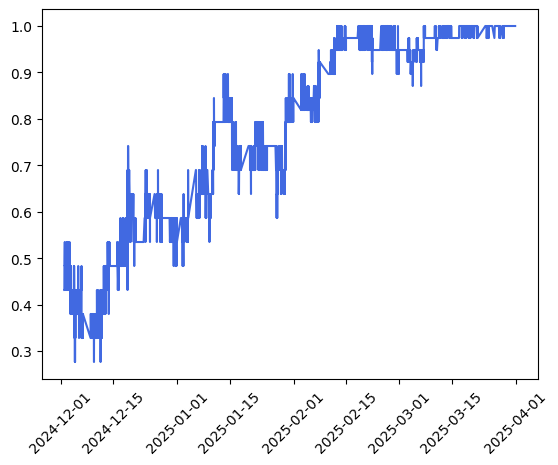

In [17]:
import matplotlib.pyplot as plt

plt.plot(imp_df["time"],imp_df['prob_no_change'], color='royalblue', linewidth=1.5)
plt.xticks(rotation=45)
plt.show()